# Week 6 - Introduction to Machine Learning
## Exercise 19: Find another dataset on any of data hosting websites (such as UCI or Kaggle) download it and repeat all the steps on it.

In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import matplotlib.pyplot as plt
import numpy as np

### Exercise 5: To open the dataset, we will be using Pandas library. Thus, initially we need to import the necessary libraries:

In [2]:
file_name = 'dataset-facebook.csv'

df = pd.read_csv(file_name, sep=';') 

display(df.head())

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393


In [6]:
print(df.head())

   Page total likes    Type  Category  Post Month  Post Weekday  Post Hour  \
0            139441   Photo         2          12             4          3   
1            139441  Status         2          12             3         10   
2            139441   Photo         3          12             3          3   
3            139441   Photo         2          12             2         10   
4            139441   Photo         2          12             2          3   

   Paid  Lifetime Post Total Reach  Lifetime Post Total Impressions  \
0   0.0                       2752                             5091   
1   0.0                      10460                            19057   
2   0.0                       2413                             4373   
3   1.0                      50128                            87991   
4   0.0                       7244                            13594   

   Lifetime Engaged Users  Lifetime Post Consumers  \
0                     178                      109

### Exercise 6: Now we can start analysing the data to get good understating of it.

In [7]:
# Display basic information about the dataset 
print("Shape of the DataFrame:") 
print(df.shape) 

print("\nColumns in the DataFrame:") 
print(df.columns)

Shape of the DataFrame:
(500, 19)

Columns in the DataFrame:
Index(['Page total likes', 'Type', 'Category', 'Post Month', 'Post Weekday',
       'Post Hour', 'Paid', 'Lifetime Post Total Reach',
       'Lifetime Post Total Impressions', 'Lifetime Engaged Users',
       'Lifetime Post Consumers', 'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post',
       'comment', 'like', 'share', 'Total Interactions'],
      dtype='object')


### Exercise 7: To get a statistical analysis of the data we can use pandas describe tool, as follows:

In [8]:
# Display summary statistics of numerical columns 
print("\nSummary Statistics:") 
display(df.describe())


Summary Statistics:


,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
count,500.000000,500.000000,500.000000,500.000000,500.000000,499.000000,500.00000,5.000000e+02,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.00000,499.000000,496.000000,500.000000
mean,123194.176000,1.880000,7.038000,4.150000,7.840000,0.278557,13903.36000,2.958595e+04,920.344000,798.772000,1415.130000,1.676638e+04,6585.488000,609.986000,7.48200,177.945892,27.266129,212.120000
std,16272.813214,0.852675,3.307936,2.030701,4.368589,0.448739,22740.78789,7.680325e+04,985.016636,882.505013,2000.594118,5.979102e+04,7682.009405,612.725618,21.18091,323.398742,42.613292,380.233118
min,81370.000000,1.000000,1.000000,1.000000,1.000000,0.000000,238.00000,5.700000e+02,9.000000,9.000000,9.000000,5.670000e+02,236.000000,9.000000,0.00000,0.000000,0.000000,0.000000
25%,112676.000000,1.000000,4.000000,2.000000,3.000000,0.000000,3315.00000,5.694750e+03,393.750000,332.500000,509.250000,3.969750e+03,2181.500000,291.000000,1.00000,56.500000,10.000000,71.000000
50%,129600.000000,2.000000,7.000000,4.000000,9.000000,0.000000,5281.00000,9.051000e+03,625.500000,551.500000,851.000000,6.255500e+03,3417.000000,412.000000,3.00000,101.000000,19.000000,123.500000
75%,136393.000000,3.000000,10.000000,6.000000,11.000000,1.000000,13168.00000,2.208550e+04,1062.000000,955.500000,1463.000000,1.486050e+04,7989.000000,656.250000,7.00000,187.500000,32.250000,228.500000
max,139441.000000,3.000000,12.000000,7.000000,23.000000,1.000000,180480.00000,1.110282e+06,11452.000000,11328.000000,19779.000000,1.107833e+06,51456.000000,4376.000000,372.00000,5172.000000,790.000000,6334.000000


### Exercise 8: To check for any missing data, we can use:

In [9]:
# Check for any missing values 
print("\nMissing Values:") 
print(df.isnull().sum())


Missing Values:
Page total likes                                                       0
Type                                                                   0
Category                                                               0
Post Month                                                             0
Post Weekday                                                           0
Post Hour                                                              0
Paid                                                                   1
Lifetime Post Total Reach                                              0
Lifetime Post Total Impressions                                        0
Lifetime Engaged Users                                                 0
Lifetime Post Consumers                                                0
Lifetime Post Consumptions                                             0
Lifetime Post Impressions by people who have liked your Page           0
Lifetime Post reach by people who 

### Exercise 9: To check for duplicated row, we can use:

In [11]:
# Check for any duplicate rows 
print(f"Number of Duplicate Rows: {df.duplicated().sum()}")

Number of Duplicate Rows: 0


### Exercise 10: To check for column data types, we can use:

In [12]:
print("\nData types of the columns:") 
print(df.dtypes)


Data types of the columns:
Page total likes                                                         int64
Type                                                                    object
Category                                                                 int64
Post Month                                                               int64
Post Weekday                                                             int64
Post Hour                                                                int64
Paid                                                                   float64
Lifetime Post Total Reach                                                int64
Lifetime Post Total Impressions                                          int64
Lifetime Engaged Users                                                   int64
Lifetime Post Consumers                                                  int64
Lifetime Post Consumptions                                               int64
Lifetime Post Impression

### Exercise 11: We can asse the importance of the feature using the correlation matrix as follows:

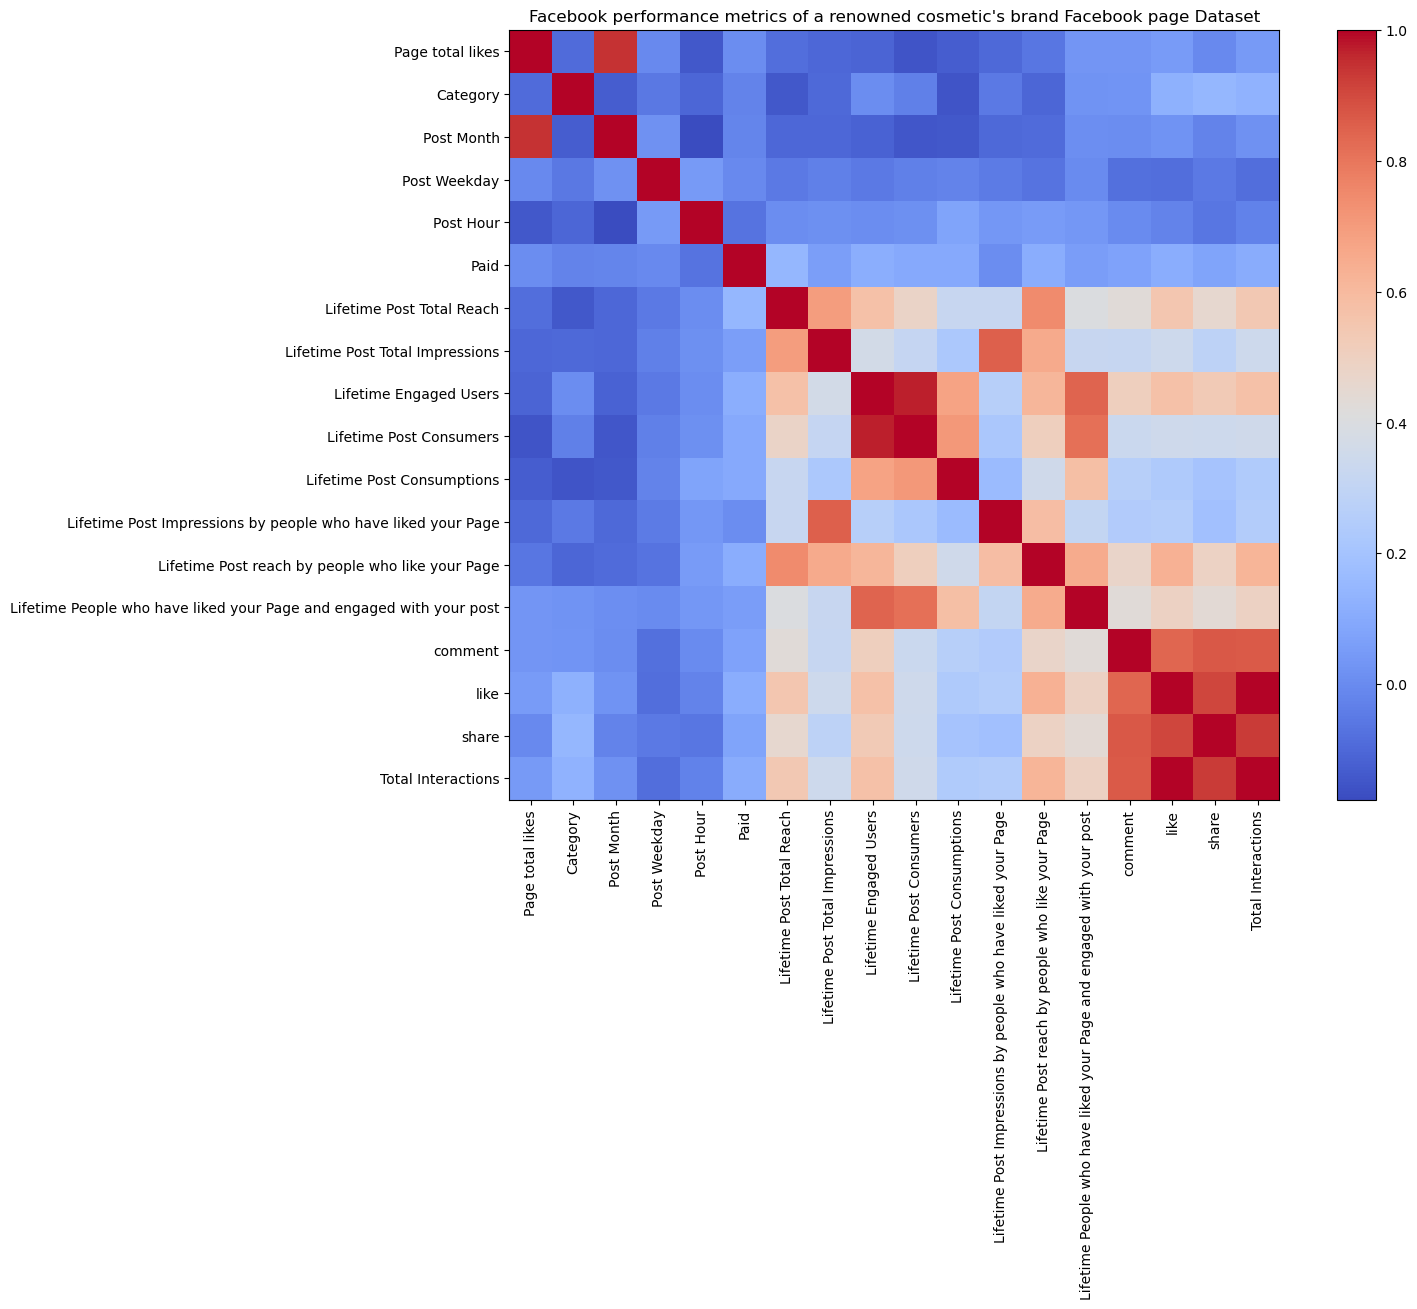

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
Page total likes,1.000000,-0.091142,0.941192,-0.005401,-0.143807,0.005341,-0.083245,-0.102540,-0.111922,-0.149129,-0.128240,-0.096109,-0.060516,0.033699,0.031891,0.053276,-0.004859,0.045231
Category,-0.091142,1.000000,-0.127690,-0.053239,-0.107383,-0.022474,-0.142073,-0.094368,0.003392,-0.031172,-0.149443,-0.047803,-0.104456,0.021569,0.027842,0.126786,0.149211,0.127307
Post Month,0.941192,-0.127690,1.000000,0.017050,-0.176390,-0.018934,-0.102506,-0.101616,-0.115898,-0.147083,-0.142829,-0.094624,-0.092012,0.010956,0.006174,0.025633,-0.021859,0.018362
Post Weekday,-0.005401,-0.053239,0.017050,1.000000,0.045857,-0.001963,-0.050155,-0.033674,-0.048382,-0.029602,-0.021565,-0.046442,-0.068741,0.001144,-0.077209,-0.082322,-0.048713,-0.081049
Post Hour,-0.143807,-0.107383,-0.176390,0.045857,1.000000,-0.069464,0.003338,0.012747,0.003879,0.012222,0.078759,0.038892,0.052412,0.038011,0.000922,-0.024523,-0.058680,-0.027421
Paid,0.005341,-0.022474,-0.018934,-0.001963,-0.069464,1.000000,0.146631,0.062564,0.117014,0.097679,0.097462,0.003211,0.110043,0.054163,0.075761,0.110694,0.076821,0.107739
Lifetime Post Total Reach,-0.083245,-0.142073,-0.102506,-0.050155,0.003338,0.146631,1.000000,0.694926,0.570629,0.477908,0.324362,0.322254,0.743053,0.400756,0.427155,0.545185,0.456312,0.538597
Lifetime Post Total Impressions,-0.102540,-0.094368,-0.101616,-0.033674,0.012747,0.062564,0.694926,1.000000,0.368553,0.315201,0.226081,0.850787,0.651933,0.323843,0.316612,0.345091,0.286829,0.343358
Lifetime Engaged Users,-0.111922,0.003392,-0.115898,-0.048382,0.003879,0.117014,0.570629,0.368553,1.000000,0.968213,0.676840,0.260346,0.612080,0.839279,0.505806,0.569565,0.531261,0.572159
Lifetime Post Consumers,-0.149129,-0.031172,-0.147083,-0.029602,0.012222,0.097679,0.477908,0.315201,0.968213,1.000000,0.706666,0.222941,0.503847,0.813510,0.334621,0.349152,0.343048,0.354502


In [5]:
# Selecting only numerical columns 
numerical_columns = df.select_dtypes(include=['int64', 'float64']) 

# Calculating correlations 
correlations = numerical_columns.corr() 

# Creating a basic heatmap to visualize the correlations 
plt.figure(figsize=(15, 10)) 
plt.imshow(correlations, cmap='coolwarm', interpolation='nearest') 
plt.colorbar() 
plt.xticks(range(len(correlations)), correlations.columns, rotation=90) 
plt.yticks(range(len(correlations)), correlations.columns) 
plt.title('Facebook performance metrics of a renowned cosmetic\'s brand Facebook page Dataset') 
plt.show()

correlations

### Exercise 12: To understand the different distributions

In [18]:
# Generate value counts for categorical variables 
print("\nValue Counts for Categorical Variables:") 
print(df['Type'].value_counts())


Value Counts for Categorical Variables:
Type
Photo     426
Status     45
Link       22
Video       7
Name: count, dtype: int64


### Exercise 13: We can easily visualise the data using matplotlib

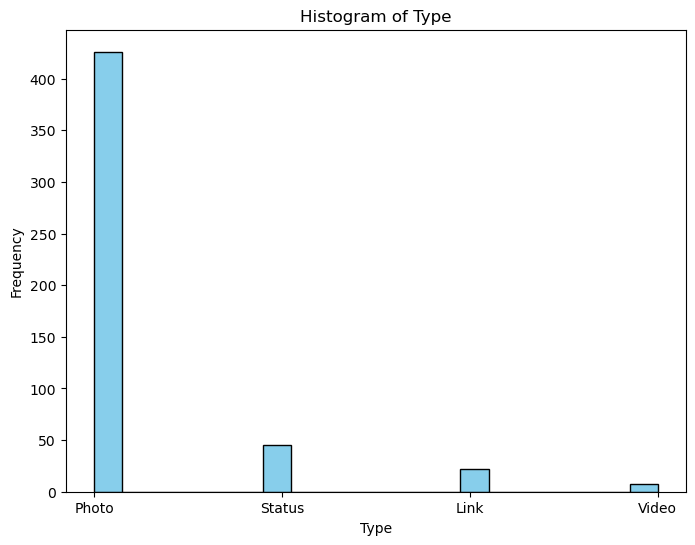

In [20]:
# Example: Histogram of Type 
plt.figure(figsize=(8, 6)) 
plt.hist(df['Type'], bins=20, color='skyblue', edgecolor='black') 
plt.title('Histogram of Type') 
plt.xlabel('Type') 
plt.ylabel('Frequency') 
plt.show()

### Exercise 14:

In [21]:
# Selecting the feature and target variables 
X = df[['Lifetime Post Total Reach']] # Feature variable 
y = df['Total Interactions'] # Target variable

# Splitting the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Creating and fitting the model 
model = LinearRegression() 
model.fit(X_train, y_train)

# Predicting the target values 
y_pred = model.predict(X_test)

### Exercise 15: Measure the model performance using Mean Absolute Error, Mean Squared Error, and Calculating R-squared.

In [22]:
# Calculating Mean Absolute Error 
mae = mean_absolute_error(y_test, y_pred) 
print("Mean Absolute Error:", mae) 

# Calculating Mean Squared Error 
mse = mean_squared_error(y_test, y_pred) 
print("Mean Squared Error:", mse) 

# Calculating R-squared 
r2 = r2_score(y_test, y_pred) 
print("R-squared:", r2)

Mean Absolute Error: 111.16638199507514
Mean Squared Error: 36899.76179957396
R-squared: 0.479521997934962


### Exercise 16: Visualise the model performance

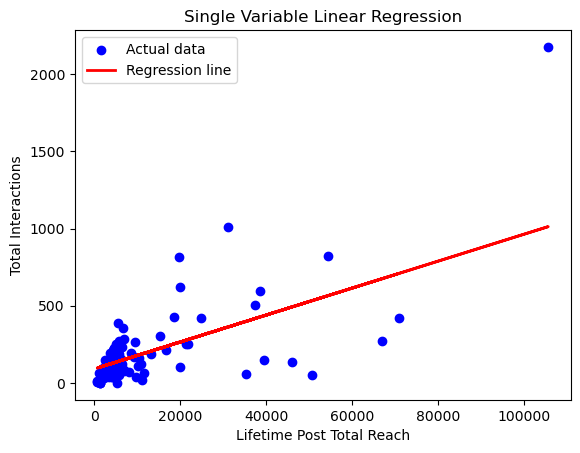

In [24]:
# Plotting the data points and the regression line 
plt.scatter(X_test, y_test, color='blue', label='Actual data') 
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line') 
plt.title('Single Variable Linear Regression') 
plt.xlabel('Lifetime Post Total Reach') 
plt.ylabel('Total Interactions') 
plt.legend() 
plt.show()

### Exercise 17: Try 3 different independent variables and compare the results. Write a comment on the best variable for the prediction (make sure that the variable you are testing is a numeric one as we cannot use a string as a number).

Performance for Post Month:
Mean Absolute Error (MAE): 157.095920594721
Mean Squared Error (MSE): 71990.2451036387
R-squared (R²): -0.015435794497374866 



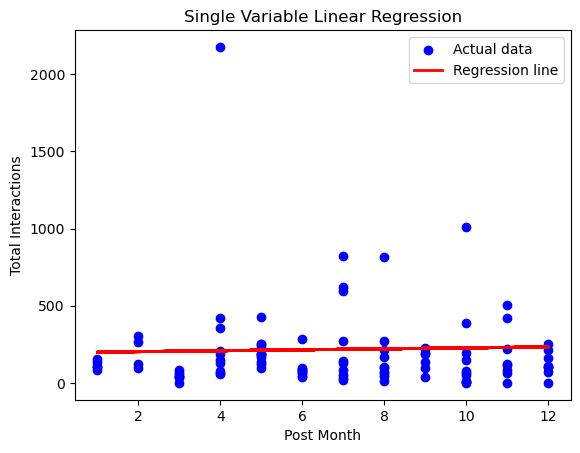


Performance for Lifetime Post Total Reach:
Mean Absolute Error (MAE): 111.16638199507514
Mean Squared Error (MSE): 36899.76179957396
R-squared (R²): 0.479521997934962 



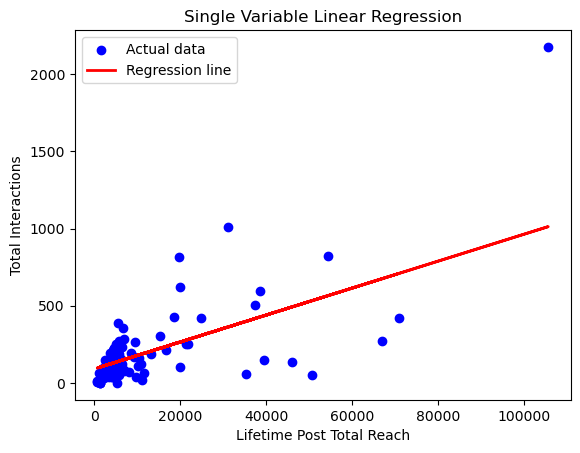


Performance for Lifetime Post Total Impressions:
Mean Absolute Error (MAE): 132.69690629062876
Mean Squared Error (MSE): 58042.734310465996
R-squared (R²): 0.181296438920319 



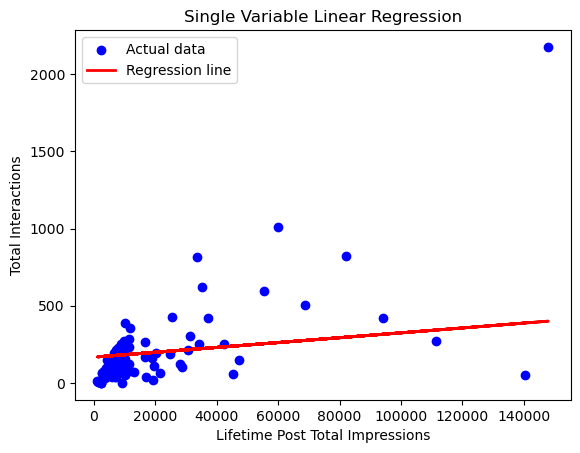

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# List of independent variables to test
independent_variables = ['Post Month', 'Lifetime Post Total Reach', 'Lifetime Post Total Impressions']

# Dictionary to store the results
results = {}

for var in independent_variables:
    # Selecting the feature and target variables
    X = df[[var]]  # Feature variable
    y = df['Total Interactions']  # Target variable

    # Splitting the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    # Creating and fitting the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predicting the target values
    y_pred = model.predict(X_test)

    # Evaluating the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Storing the results
    results[var] = {'MAE': mae, 'MSE': mse, 'R2': r2}

    # Print the performance metrics for each variable
    print(f"Performance for {var}:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"R-squared (R²): {r2} \n")

    # Plotting the data points and the regression line 
    plt.scatter(X_test, y_test, color='blue', label='Actual data') 
    plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line') 
    plt.title('Single Variable Linear Regression') 
    plt.xlabel(var) 
    plt.ylabel('Total Interactions') 
    plt.legend() 
    plt.show()

    print()


#### Finding the best variable based on Mean Absolute Error (MAE)

The best variable for prediction based on MAE is Lifetime Post Total Reach with a MAE value of 111.16638199507514. 



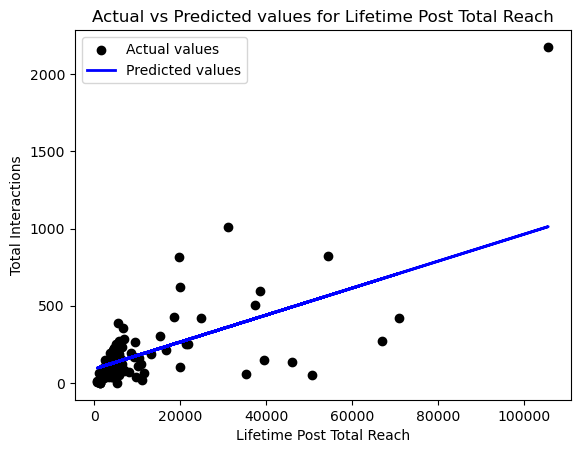

In [32]:
# Finding the best variable based on Mean Absolute Error (MAE)
best_var_mae = min(results, key=lambda x: results[x]['MAE'])
print(f"The best variable for prediction based on MAE is {best_var_mae} with a MAE value of {results[best_var_mae]['MAE']}. \n")

# Plotting the actual vs predicted values for the best variable based on MAE
X = df[[best_var_mae]]
y = df['Total Interactions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='black', label='Actual values')
plt.plot(X_test, y_pred, color='blue', linewidth=2, label='Predicted values')
plt.title(f'Actual vs Predicted values for {best_var_mae}')
plt.xlabel(best_var_mae)
plt.ylabel('Total Interactions')
plt.legend()
plt.show()


#### Finding the best variable based on Mean Squared Error (MSE)

The best variable for prediction based on MSE is Lifetime Post Total Reach with a MSE value of 36899.76179957396. 



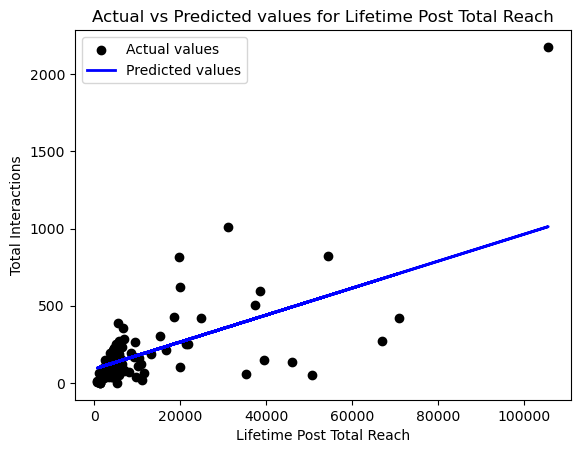

In [33]:
# Finding the best variable based on Mean Squared Error (MSE)
best_var_mse = min(results, key=lambda x: results[x]['MSE'])
print(f"The best variable for prediction based on MSE is {best_var_mse} with a MSE value of {results[best_var_mse]['MSE']}. \n")

# Plotting the actual vs predicted values for the best variable based on MSE
X = df[[best_var_mse]]
y = df['Total Interactions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='black', label='Actual values')
plt.plot(X_test, y_pred, color='blue', linewidth=2, label='Predicted values')
plt.title(f'Actual vs Predicted values for {best_var_mse}')
plt.xlabel(best_var_mse)
plt.ylabel('Total Interactions')
plt.legend()
plt.show()

#### Finding the best variable based on R-squared value

The best variable for prediction based on R-squared is Lifetime Post Total Reach with an R-squared value of 0.479521997934962. 



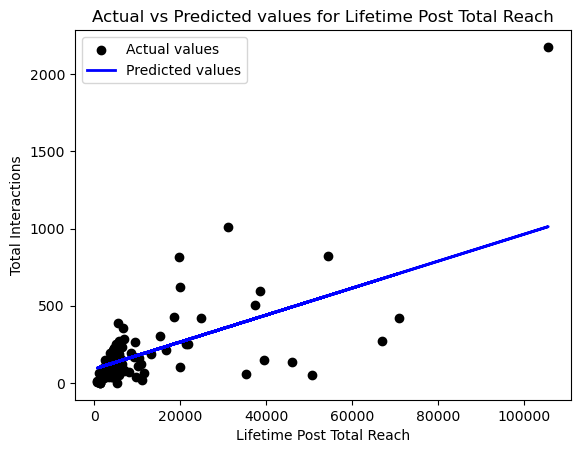

In [35]:
# Finding the best variable based on R-squared value
best_var_r2 = max(results, key=lambda x: results[x]['R2'])
print(f"The best variable for prediction based on R-squared is {best_var_r2} with an R-squared value of {results[best_var_r2]['R2']}. \n")

# Plotting the actual vs predicted values for the best variable based on R-squared
X = df[[best_var_r2]]
y = df['Total Interactions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='black', label='Actual values')
plt.plot(X_test, y_pred, color='blue', linewidth=2, label='Predicted values')
plt.title(f'Actual vs Predicted values for {best_var_r2}')
plt.xlabel(best_var_r2)
plt.ylabel('Total Interactions')
plt.legend()
plt.show()


Comment: According to the performance testing results, "Lifetime Post Total Reach " can be assumed as the best independent variable for the prediction among these three independent variables: Post Month, Lifetime Post Total Reach, and Lifetime Post Total Impressions.

### Exercise 18: Now we will use multiple features to predict the grade and compare the result to the single viable. To do so we need to redefine the X variable as follows. (Note: we cannot plot multidimensional plots, thus you should not plot the data as in exercise 16)

Mean Absolute Error: 36.787860084862025
Mean Squared Error: 5127.455588531037
R-squared: 0.9276762854218029


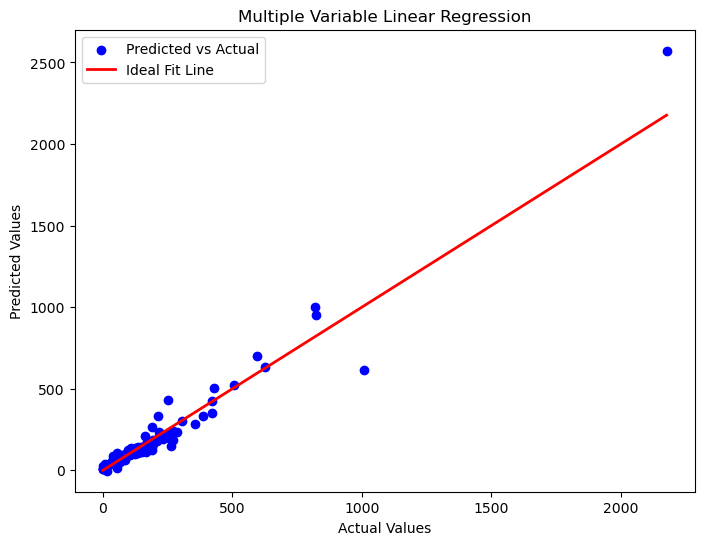

In [37]:
# Selecting the feature and target variables
X = df[['Lifetime Post Total Reach', 'Lifetime Post Total Impressions', 'Lifetime Engaged Users', 'Lifetime Post Consumers', 
        'Lifetime Post Consumptions', 'Lifetime Post Impressions by people who have liked your Page', 
        'Lifetime Post reach by people who like your Page', 'Lifetime People who have liked your Page and engaged with your post']]
y = df['Total Interactions']  # Target variable

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Creating and fitting the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting the target values
y_pred = model.predict(X_test)

# Calculating Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Calculating Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Calculating R-squared
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

# Visualization: Actual vs Predicted Values with Line Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label='Ideal Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Multiple Variable Linear Regression')
plt.legend()
plt.show()

#### Compare the result to the single viable

Mean Absolute Error: 116.02188377234832
Mean Squared Error: 43875.149241604646
R-squared: 0.38113286092162735


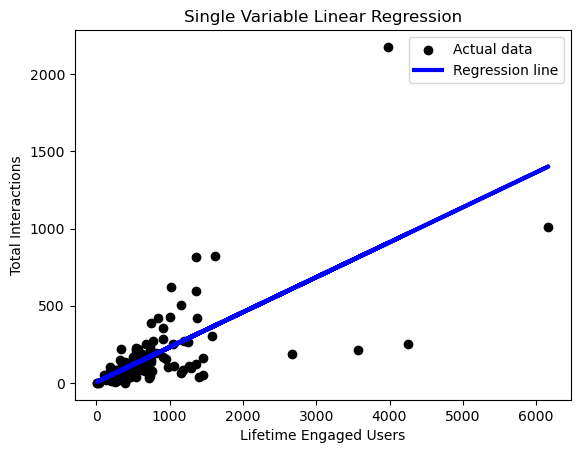

In [39]:
# Selecting the feature and target variables 
X = df[['Lifetime Engaged Users']] # Feature variable 
y = df['Total Interactions'] # Target variable

# Splitting the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Creating and fitting the model 
model = LinearRegression() 
model.fit(X_train, y_train)

# Predicting the target values 
y_pred = model.predict(X_test)

# Calculating Mean Absolute Error 
mae = mean_absolute_error(y_test, y_pred) 
print("Mean Absolute Error:", mae) 

# Calculating Mean Squared Error 
mse = mean_squared_error(y_test, y_pred) 
print("Mean Squared Error:", mse) 

# Calculating R-squared 
r2 = r2_score(y_test, y_pred) 
print("R-squared:", r2)

# Plotting the data points and the regression line 
plt.scatter(X_test, y_test, color='black', label='Actual data') 
plt.plot(X_test, y_pred, color='blue', linewidth=3, label='Regression line') 
plt.title('Single Variable Linear Regression') 
plt.xlabel('Lifetime Engaged Users') 
plt.ylabel('Total Interactions') 
plt.legend() 
plt.show()

By comparing the performance of a single-variable model (using just one feature) to a model with multiple features, we can see if using additional data points (features) improves the accuracy of predicting the total interactions of a renowned cosmetic brand Facebook page.

#### Look back at the corelation matrix and find the most useful features you may use to get best results. 

The most useful features for predicting Total Interactions are like, share, and comment, as they have the strongest positive correlations. Additionally, Lifetime Post reach by people who like your Page, Lifetime Engaged Users, and Lifetime Post Total Reach are also important features to consider due to their moderate positive correlations. These features should be prioritized in predictive modeling or analysis tasks related to predicting Total Interactions.

## References

Moro, S, Rita, P, and Vala, B., 2016, 'Facebook Metrics. UCI Machine Learning Repository', https://doi.org/10.24432/C5QK55.